# CDLD: KMLE and EdNet

Final paper tables and figures. Run all cells from this repository directory. Run-level means and contrasts are recomputed from `data/`; confidence intervals use the final saved inference summaries. See README for training and raw-data instructions.

In [1]:
"""Rebuild paper tables and figures from the final run-level results."""
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
ROOT=Path.cwd()
DATA=ROOT/'data'

def reproduce(out=None):
    out=Path(out) if out else ROOT/'outputs'
    out.mkdir(parents=True,exist_ok=True)
    read=lambda name:pd.read_csv(DATA/(name+'.csv'))
    raw=read('irt_all_metrics')
    means=raw.groupby(['dataset','unit','target','features'],as_index=False).r2.mean()
    table1=means.pivot(index=['dataset','unit','target'],columns='features',values='r2')[['B1','B1+S','B1+L']].reset_index()
    ci=read('irt_paired_bootstrap_summary')
    for base,label in [('B1','summary'),('B1+S','svd64')]:
        c=ci[(ci.baseline==base)&(ci.extended=='B1+L')][['dataset','unit','target','estimate','ci_low','ci_high']]
        table1=table1.merge(c.rename(columns={k:f'{label}_{k}' for k in ['estimate','ci_low','ci_high']}),on=['dataset','unit','target'],validate='one_to_one')
        np.testing.assert_allclose(table1['B1+L']-table1[base],table1[f'{label}_estimate'],atol=1e-10)
    table1=table1.rename(columns={'B1':'Summary','B1+S':'Summary+SVD64','B1+L':'Summary+CDLD64'})
    part=read('part_seed_metrics').groupby('features',as_index=False)[['log_loss','balanced_accuracy','macro_f1']].mean()
    pred=read('rq1_seed_metrics').groupby(['dataset','protocol','model','k'],as_index=False)[['auc','score_correlation','log_loss','brier','accuracy']].mean()
    table3=pred[(pred.model.isin(['CDLD','2PL']))&((pred.protocol=='warm')|((pred.protocol=='cold')&(pred.k==40)))].copy()
    ni=read('rq1_cold_ni');table3=table3.merge(ni[ni.comparator=='2PL'][['dataset','difference','repeat_lower_one_sided95','repeat_noninferior']],on='dataset',how='left')
    table3['repeat_noninferior']=table3['repeat_noninferior'].astype(object)
    table3.loc[table3.protocol=='warm',['difference','repeat_lower_one_sided95','repeat_noninferior']]=np.nan
    tables={'table1_irt':table1,'table2_part':part,'table2_part_difference':read('rq2b_log_loss_corrected'),'table3_prediction':table3,'supplement_prediction':pred,'supplement_noninferiority':ni,'supplement_irt_all':raw.groupby(['dataset','unit','target','features']).r2.agg(mean='mean',minimum='min',maximum='max').reset_index(), 'supplement_rt_sample':read('rt_sample_counts'),'supplement_irt_initial':read('rq2a_summary'),'supplement_rt_means':read('rt_seed_metrics').groupby('condition',as_index=False)[['mse','rmse','r2']].mean(),'supplement_rt_differences':read('rt_contrasts'),'supplement_metadata_means':read('augmentation_seed_metrics').groupby('protocol',as_index=False).mean(numeric_only=True).drop(columns='seed'),'supplement_metadata_differences':read('augmentation_contrasts'),'supplement_csp':read('csp_gates'),'supplement_tag':read('tag_summary'),'supplement_irt_stability':read('irt_stability_unaligned')}
    for name,frame in tables.items():frame.to_csv(out/(name+'.csv'),index=False)
    plt.rcParams.update({'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
    targets=['Rasch_theta','2PL_theta','Rasch_b','2PL_b','2PL_log_a']
    labels=['Rasch ability','2PL ability','Rasch difficulty','2PL difficulty','2PL log discrimination']
    fig,axes=plt.subplots(1,2,figsize=(11,4.6),sharex=True,sharey=True)
    for ax,ds in zip(axes,['KMLE','EdNet']):
        for base,offset,color,marker,label in [('B1',-.12,'#007997','o','vs Summary'),('B1+S',.12,'#c16b20','s','vs Summary+SVD64')]:
            g=ci[(ci.dataset==ds)&(ci.baseline==base)&(ci.extended=='B1+L')].set_index('target').loc[targets]
            ax.errorbar(g.estimate,np.arange(5)+offset,xerr=[g.estimate-g.ci_low,g.ci_high-g.estimate],fmt=marker,color=color,capsize=3,label=label)
        ax.axvline(0,color='gray',ls='--');ax.set(title=ds,yticks=range(5),yticklabels=labels,xlabel='R² difference: Summary+CDLD64 − comparator',xlim=(-.25,.35))
    axes[0].invert_yaxis();axes[1].legend(frameon=False);fig.tight_layout();fig.savefig(out/'figure1.png',dpi=240);plt.close(fig)
    fig,axes=plt.subplots(1,2,figsize=(10,4),sharey=True)
    for ax,ds in zip(axes,['KMLE','EdNet']):
        for model in ['CDLD','2PL','Rasch']:
            g=pred[(pred.dataset==ds)&(pred.protocol=='cold')&(pred.model==model)].sort_values('k')
            ax.plot(g.k,g.score_correlation,'o-',label=model)
        ax.set(title=ds,xlabel='Adaptation responses per student',xticks=[0,4,8,12,16,20,40])
    axes[0].set_ylabel('Student score correlation (Pearson r)');axes[1].legend(frameon=False);fig.tight_layout();fig.savefig(out/'figure2.png',dpi=240);plt.close(fig)
    return tables


from IPython.display import display, Image
tables = reproduce()
print(f"Generated {len(tables)} tables and 2 figures.")

Generated 16 tables and 2 figures.


## table1 irt

In [2]:
display(tables['table1_irt'])

,dataset,unit,target,Summary,Summary+SVD64,Summary+CDLD64,summary_estimate,summary_ci_low,summary_ci_high,svd64_estimate,svd64_ci_low,svd64_ci_high
0,EdNet,item,2PL_b,0.586829,0.578238,0.642120,0.055291,0.042273,0.069837,6.388188e-02,0.045543,0.086132
1,EdNet,item,2PL_log_a,0.672681,0.698217,0.892308,0.219628,0.206565,0.232996,1.940910e-01,0.174342,0.218312
2,EdNet,item,Rasch_b,0.959692,0.950013,0.992582,0.032889,0.031290,0.034583,4.256884e-02,0.027660,0.069202
3,EdNet,student,2PL_theta,0.676883,0.742475,0.975719,0.298836,0.280657,0.321579,2.332436e-01,0.217498,0.253569
4,EdNet,student,Rasch_theta,0.712580,0.774776,0.973751,0.261172,0.245060,0.280619,1.989751e-01,0.184621,0.215862
5,KMLE,item,2PL_b,0.361137,0.385322,0.399339,0.038202,-0.222078,0.146609,1.401669e-02,-0.192904,0.180758
6,KMLE,item,2PL_log_a,0.875872,0.894987,0.921639,0.045767,0.016348,0.084210,2.665244e-02,0.009143,0.045696
7,KMLE,item,Rasch_b,0.999988,0.999985,0.999984,-0.000004,-0.000006,-0.000002,-2.874325e-07,-0.000003,0.000002
8,KMLE,student,2PL_theta,0.928860,0.959409,0.984329,0.055470,0.050821,0.060559,2.492000e-02,0.021234,0.028726
9,KMLE,student,Rasch_theta,0.982998,0.986977,0.986383,0.003385,0.002316,0.004421,-5.941600e-04,-0.001661,0.000486


## table2 part

In [3]:
display(tables['table2_part'])

,features,log_loss,balanced_accuracy,macro_f1
0,irt_response_controls,1.538433,0.184373,0.160601
1,irt_response_controls_plus_latent64,1.274632,0.341292,0.346025


## table2 part difference

In [4]:
display(tables['table2_part_difference'])

,definition,baseline_log_loss,extended_log_loss,delta_log_loss,ci_low,ci_high
0,float64,1.538433,1.274632,0.263801,0.251637,0.276209
1,legacy_1e12,1.536733,1.274417,0.262316,0.250713,0.274137


## table3 prediction

In [5]:
display(tables['table3_prediction'])

,dataset,protocol,model,k,auc,score_correlation,log_loss,brier,accuracy,difference,repeat_lower_one_sided95,repeat_noninferior
0,EdNet,cold,2PL,40,0.762054,0.711879,0.529054,0.177151,0.73625,-0.009624,-0.022594,False
1,EdNet,cold,CDLD,40,0.758160,0.702255,0.532971,0.178522,0.73415,-0.009624,-0.022594,False
2,EdNet,warm,2PL,-1,0.771801,0.800433,0.521179,0.174154,0.73955,NaN,NaN,NaN
3,EdNet,warm,CDLD,-1,0.771352,0.789939,0.522235,0.174487,0.73931,NaN,NaN,NaN
4,KMLE,cold,2PL,40,0.839765,0.695356,0.427837,0.138977,0.79684,-0.017901,-0.027044,False
5,KMLE,cold,CDLD,40,0.836162,0.677455,0.434703,0.140607,0.79468,-0.017901,-0.027044,False
6,KMLE,warm,2PL,-1,0.845100,0.776226,0.421919,0.137089,0.79920,NaN,NaN,NaN
7,KMLE,warm,CDLD,-1,0.844564,0.771227,0.424247,0.137610,0.79923,NaN,NaN,NaN


## Figure 1

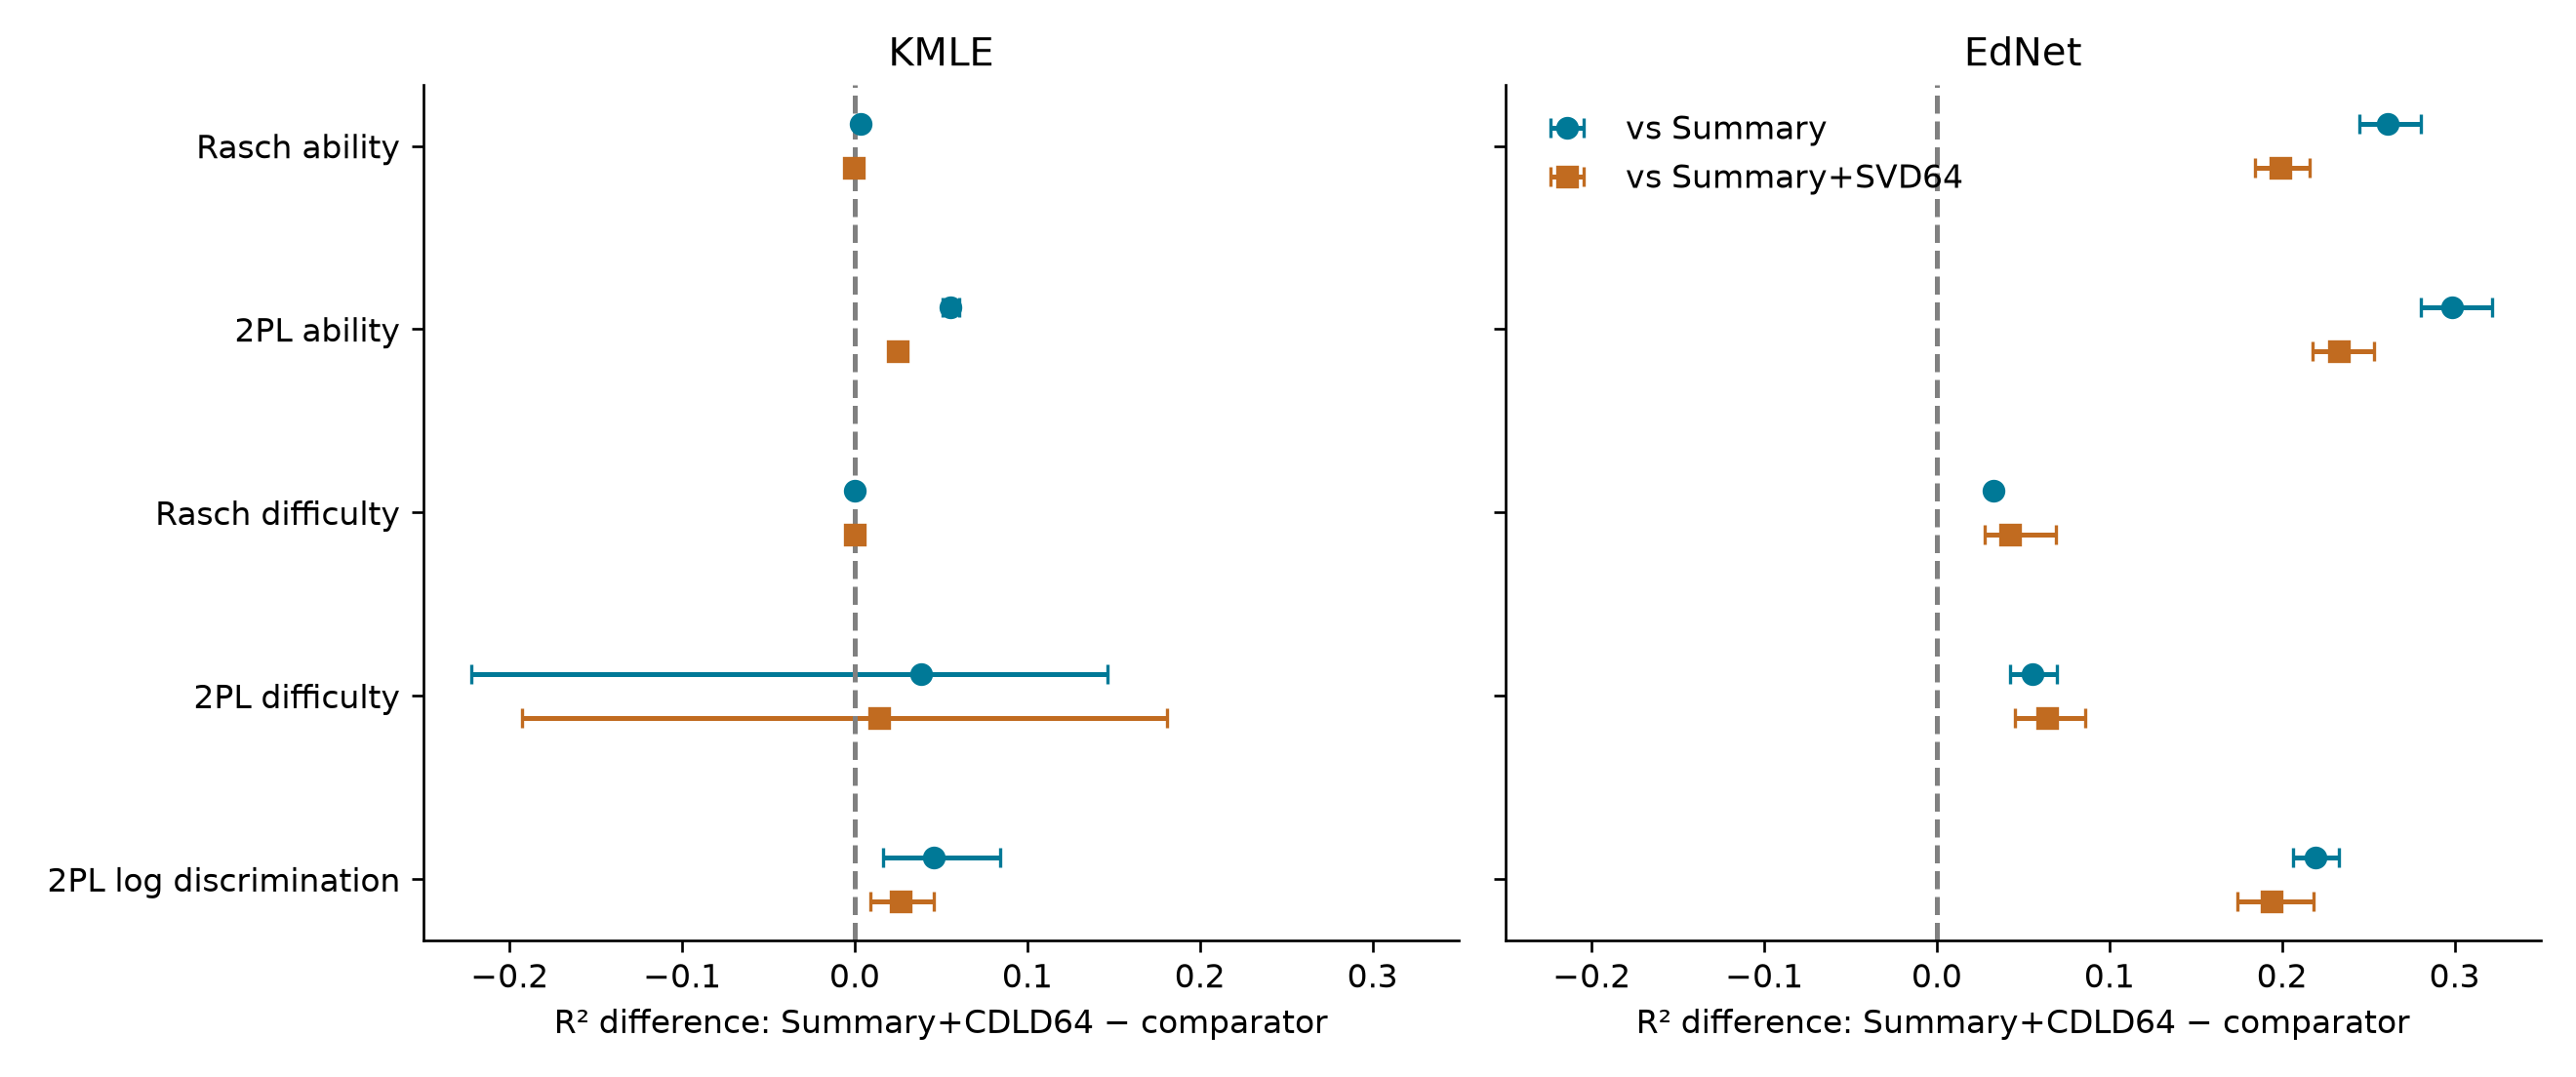

In [6]:
display(Image(filename="outputs/figure1.png"))

## Figure 2

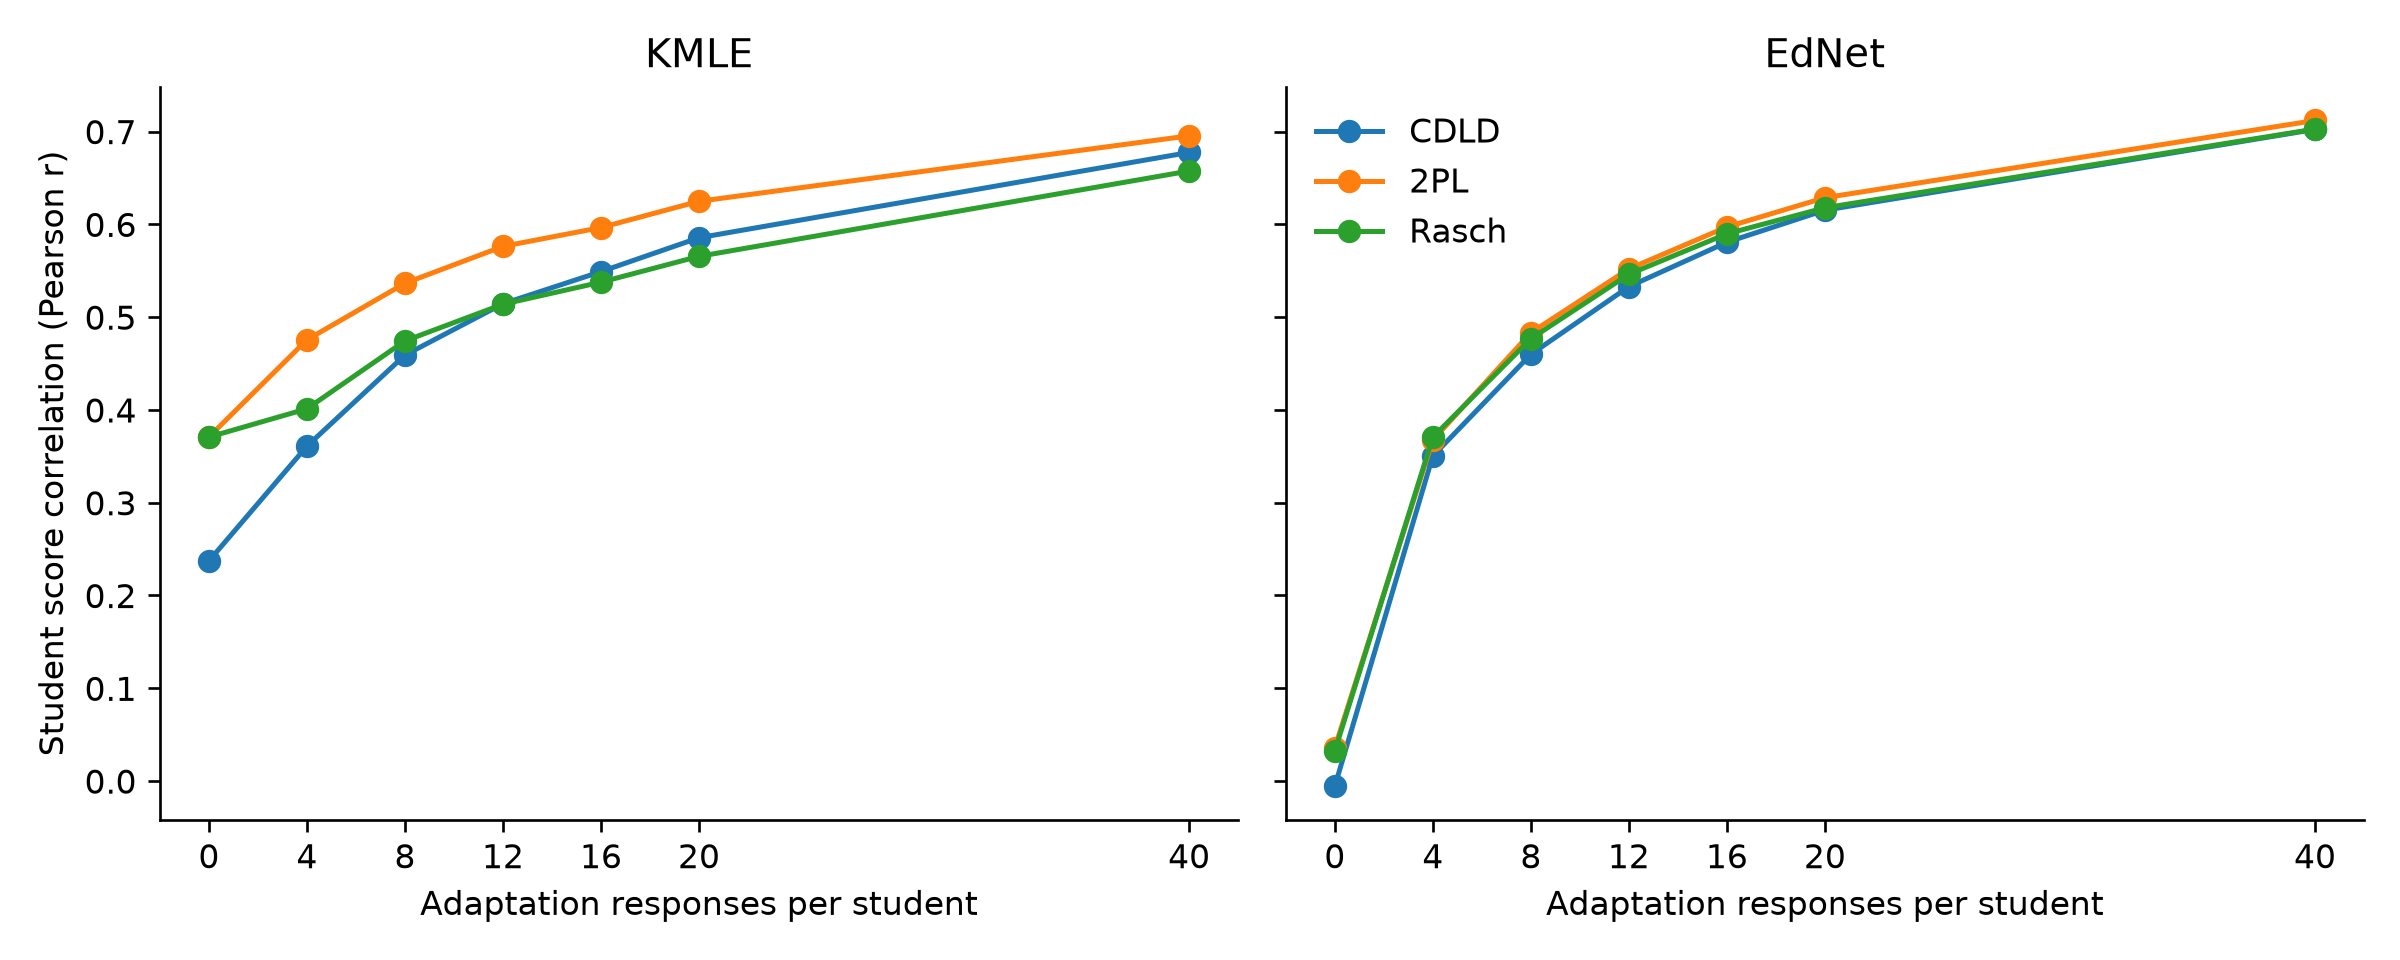

In [7]:
display(Image(filename="outputs/figure2.png"))

## Supplementary results

In [8]:
for name, table in tables.items():
    if name.startswith("supplement_"):
        print(name)
        display(table)

supplement_prediction


,dataset,protocol,model,k,auc,score_correlation,log_loss,brier,accuracy
0,EdNet,cold,2PL,0,0.711750,0.035823,0.591085,0.202764,0.68569
1,EdNet,cold,2PL,4,0.728345,0.367428,0.563708,0.191192,0.70994
2,EdNet,cold,2PL,8,0.738317,0.483135,0.551531,0.186062,0.71953
3,EdNet,cold,2PL,12,0.745251,0.551910,0.544395,0.183206,0.72483
4,EdNet,cold,2PL,16,0.749704,0.597136,0.539958,0.181480,0.72851
...,...,...,...,...,...,...,...,...,...
75,KMLE,warm,2PL,-1,0.845100,0.776226,0.421919,0.137089,0.79920
76,KMLE,warm,CDLD,-1,0.844564,0.771227,0.424247,0.137610,0.79923
77,KMLE,warm,Constant,-1,0.500000,NaN,0.592378,0.201332,0.72061
78,KMLE,warm,Item rate,-1,0.824268,0.370428,0.443919,0.144180,0.78976


supplement_noninferiority


,dataset,comparator,difference,repeat_lower_one_sided95,repeat_lower95,repeat_upper95,conditional_lower_one_sided95,margin,repeat_noninferior,global_student_union_n
0,KMLE,Rasch,0.020049,0.008117,0.005828,0.034731,0.011718,-0.01,True,1843
1,KMLE,2PL,-0.017901,-0.027044,-0.029058,-0.007675,-0.023376,-0.01,False,1843
2,EdNet,Rasch,-0.000361,-0.015682,-0.019501,0.014321,-0.006880,-0.01,False,2480
3,EdNet,2PL,-0.009624,-0.022594,-0.026745,0.001759,-0.014725,-0.01,False,2480


supplement_irt_all


...

,dataset,method,point,lower_two_sided95,upper_two_sided95,passes
0,KMLE,mean_uld64,-0.002504,-0.013214,0.008042,False
1,EdNet,mean_uld64,-0.018705,-0.037319,-0.000389,False
2,KMLE,predictor64,-0.007452,-0.020723,0.005023,False
3,EdNet,predictor64,-0.018907,-0.038028,-0.000173,False
4,KMLE,predictor_pca16,-0.015954,-0.035562,0.004384,False
5,EdNet,predictor_pca16,-0.235663,-0.290087,-0.182911,False
6,KMLE,predictor_pca64,-0.022814,-0.040910,-0.005284,False
7,EdNet,predictor_pca64,-0.160747,-0.202462,-0.119651,False
8,KMLE,predictor_pca8,-0.020270,-0.044145,0.004462,False
9,EdNet,predictor_pca8,-0.250928,-0.306663,-0.192943,False


supplement_tag


,seed,eligible_tags,macro_auprc_B1,macro_auprc_M1,delta_macro_auprc,prevalence
0,42,92,0.044187,0.051799,0.007612,0.022514
1,43,92,0.044166,0.066855,0.022688,0.022514
2,44,92,0.044023,0.061442,0.017419,0.022514
3,45,92,0.044324,0.051901,0.007577,0.022515
4,46,92,0.044296,0.050629,0.006333,0.022511


supplement_irt_stability


,dataset,model,parameter,seed1,seed2,n,raw_pearson,raw_spearman,raw_rmse
0,KMLE,Rasch,b,42,43,360,0.999767,0.999773,0.036828
1,KMLE,Rasch,b,42,44,360,0.999811,0.999763,0.033136
2,KMLE,Rasch,b,42,45,360,0.999762,0.999781,0.037403
3,KMLE,Rasch,b,42,46,360,0.999624,0.999778,0.047170
4,KMLE,Rasch,b,43,44,360,0.999767,0.999778,0.037068
5,KMLE,Rasch,b,43,45,360,0.999766,0.999740,0.037725
6,KMLE,Rasch,b,43,46,360,0.999674,0.999794,0.044590
7,KMLE,Rasch,b,44,45,360,0.999775,0.999766,0.036328
8,KMLE,Rasch,b,44,46,360,0.999703,0.999763,0.041937
9,KMLE,Rasch,b,45,46,360,0.999761,0.999796,0.037342
